In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("D:/zomato.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [4]:
df.shape

(51717, 17)

In [5]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [6]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
print(df["rate"].unique())

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '-' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5'
 '3.7 /5' '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5'
 '3.2 /5' '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5'
 '1.8/5' '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5'
 '2.1 /5' '2.2 /5' '2.0 /5' '1.8 /5']


In [8]:
#remove the "/5" from rate and remove whitespaces and convert it to numeric value
df["rate"]=df["rate"].str.replace("/5", "").str.strip()
df["rate"]=pd.to_numeric(df["rate"],errors="coerce")

#check
print(df["rate"].dtype)
print(df["rate"].head())

float64
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64


In [9]:
#converting votes colum to numeric
df["votes"]=pd.to_numeric(df["votes"], errors="coerce")
df["votes"].dtype

dtype('int64')

In [10]:
#removing comma and converting value to numeric
df["approx_cost(for two people)"]=df["approx_cost(for two people)"].str.replace(",","").str.strip()
df["approx_cost(for two people)"]=pd.to_numeric(df["approx_cost(for two people)"],errors="coerce")

#check
print(df["approx_cost(for two people)"].dtype)
print(df["approx_cost(for two people)"].head())

float64
0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
Name: approx_cost(for two people), dtype: float64


In [11]:
#dropping columns with no ratings
df=df.dropna(subset=["rate"]).copy()

In [12]:
df["cuisines"] = df["cuisines"].fillna("Unknown")

In [13]:
#convering "object" to "string" data type
df=df.astype({col:'string' for col in df.select_dtypes(include='object').columns})

#check
df.dtypes

url                            string[python]
address                        string[python]
name                           string[python]
online_order                   string[python]
book_table                     string[python]
rate                                  float64
votes                                   int64
phone                          string[python]
location                       string[python]
rest_type                      string[python]
dish_liked                     string[python]
cuisines                       string[python]
approx_cost(for two people)           float64
reviews_list                   string[python]
menu_item                      string[python]
listed_in(type)                string[python]
listed_in(city)                string[python]
dtype: object

In [14]:
#removing spaces and fixing capitalization
df["location"]=df["location"].str.strip().str.title()
df["rest_type"]=df["rest_type"].str.strip().str.title()
df["listed_in(type)"]=df["listed_in(type)"].str.strip().str.title()
df["listed_in(city)"]=df["listed_in(city)"].str.strip().str.title()

In [15]:
print(df[["location", "rest_type", "listed_in(type)", "listed_in(city)"]].isnull().sum())

location             0
rest_type          149
listed_in(type)      0
listed_in(city)      0
dtype: int64


In [16]:
#for missing rest_type values, we are using listed_in(type) values
df["rest_type"]=df["rest_type"].fillna(df["listed_in(type)"])

In [17]:
#exporting clean file
df.to_csv("zomato_cleaned.csv",index=False)
print("Cleaned data exported")
print(f"Shape after cleaniing {df.shape}")

Cleaned data exported
Shape after cleaniing (41665, 17)


In [18]:
#creating a separate column with all cuisines individually and removing whitespaces
df["cuisine_list"]=df["cuisines"].str.split(",").apply(lambda x: [i.strip() for i in x])
df_exploded=df.explode("cuisine_list")

In [19]:
#finding the top rated cuisine
cuisine_rating=df_exploded.groupby("cuisine_list")["rate"].mean().sort_values(ascending=False)

top5=cuisine_rating.head(5)
bottom5= cuisine_rating.tail(5)

Top 5 highest rated cuisine: cuisine_list
Cantonese        4.600000
African          4.523529
Singaporean      4.414894
Belgian          4.366667
Modern Indian    4.308276
Name: rate, dtype: float64

Lowest rated cuisine: cuisine_list
Unknown        3.490909
Kashmiri       3.431818
Drinks Only    3.300000
Paan           3.300000
Pan Asian      3.000000
Name: rate, dtype: float64


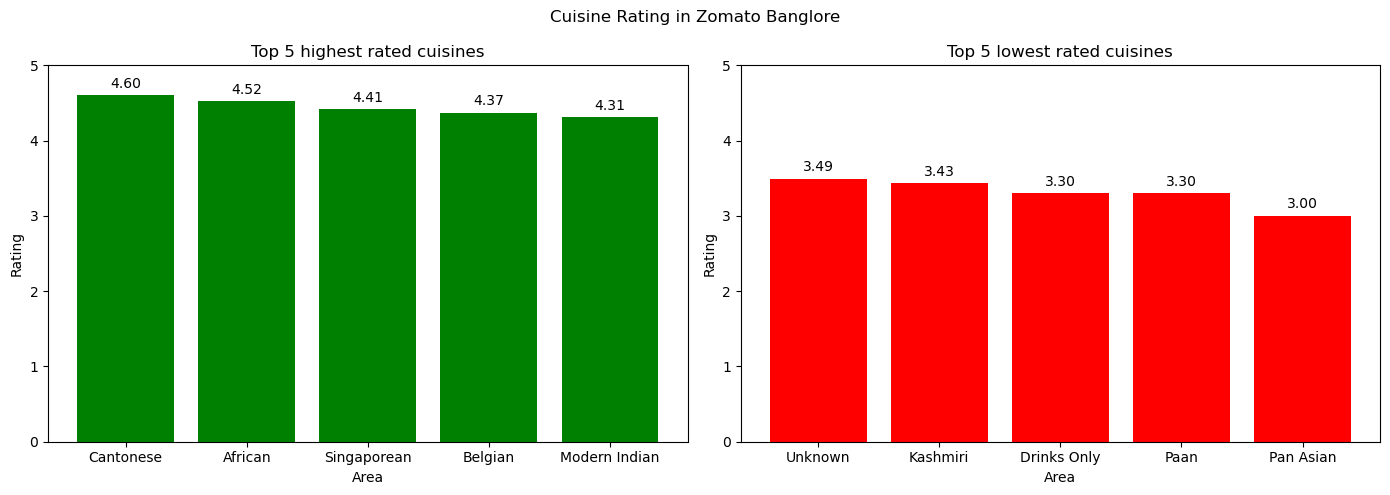

In [20]:
print("Top 5 highest rated cuisine:",top5)
print("\nLowest rated cuisine:",bottom5)

fig, ax= plt.subplots(1,2, figsize=(14,5))

ax[0].bar(top5.index, top5.values, color="green")
ax[0].set_title("Top 5 highest rated cuisines")
ax[0].set_xlabel("Area")
ax[0].set_ylabel("Rating")
ax[0].set_ylim(0,5)
for i, v in enumerate(top5.values):
    ax[0].text(i,v + 0.1, f"{v:.2f}", ha="center", fontsize=10)


ax[1].bar(bottom5.index, bottom5.values,color="red")
ax[1].set_title("Top 5 lowest rated cuisines")
ax[1].set_xlabel("Area")
ax[1].set_ylabel("Rating")
ax[1].set_ylim(0,5)
for i, v in enumerate(bottom5.values):
    ax[1].text(i,v+0.1,f"{v:.2f}", ha="center", fontsize=10)
plt.suptitle("Cuisine Rating in Zomato Banglore")
fig.tight_layout()
plt.savefig("plot1_cuisine_rating.png", dpi=150,bbox_inches="tight")
plt.show()

Interestingly, Asian cuisine appear in both highest rated and the lowest rated. It suggests that a broad cuisine label like Pan Asian does not gaurentee success, as specialized Asian restaurants are rated higher. we can also observe that premium cuisines are rated higher than the local ones.

In [21]:
#highest rated cuisine in each area
city_cuisine=df_exploded.groupby(["listed_in(city)","cuisine_list"])["rate"].mean()
top_rated_cuisine_per_city=city_cuisine.groupby("listed_in(city)").idxmax().apply(lambda x:x[1])
print(top_rated_cuisine_per_city)

listed_in(city)
Banashankari                Indonesian
Bannerghatta Road              African
Basavanagudi             Mediterranean
Bellandur                         Goan
Brigade Road                 Cantonese
Brookefield                    African
Btm                            African
Church Street                Cantonese
Electronic City                British
Frazer Town                Singaporean
Hsr                               Goan
Indiranagar                  Cantonese
Jayanagar                      African
Jp Nagar                       African
Kalyan Nagar                  Japanese
Kammanahalli                  Japanese
Koramangala 4Th Block            Sushi
Koramangala 5Th Block            Sushi
Koramangala 6Th Block            Sushi
Koramangala 7Th Block          African
Lavelle Road                 Cantonese
Malleshwaram                   Tex-Mex
Marathahalli                   African
Mg Road                      Cantonese
New Bel Road               Finger Food
Old Airpo

In [22]:
#top locations
top_locations=df.groupby("location")["rate"].mean().sort_values(ascending=False).head(15)
#top_locations

#top restraunt in each area
top_restraunts=df.sort_values("rate",ascending=False).groupby("location").first() .reset_index()[["location", "name", "rate", "cuisines"]].sort_values("rate",ascending=False)
top_restraunts

,location,name,rate,cuisines
9,Btm,AB's - Absolute Barbecues,4.9,"European, Mediterranean, North Indian, BBQ"
7,Brigade Road,Belgian Waffle Factory,4.9,Desserts
26,Indiranagar,Milano Ice Cream,4.9,"Ice Cream, Desserts"
43,Koramangala 5Th Block,Asia Kitchen By Mainland China,4.9,"Asian, Chinese, Thai, Momos"
75,Sarjapur Road,Byg Brewski Brewing Company,4.9,"Continental, North Indian, Italian, South Indi..."
...,...,...,...,...
83,Uttarahalli,Shree Mandarathi Grand,3.7,"South Indian, North Indian"
60,North Bangalore,FreshMenu,3.6,"Healthy Food, Chinese, Biryani, North Indian, ..."
87,West Bangalore,Fit Dish Fetish,3.5,Healthy Food
57,Nagarbhavi,Ayodhya Food Line,3.4,"South Indian, North Indian, Fast Food, Chinese"


C:\Users\Sana Amreen\AppData\Local\Temp\ipykernel_33948\2204829450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values,y=top_locations.index, palette="Blues_r")


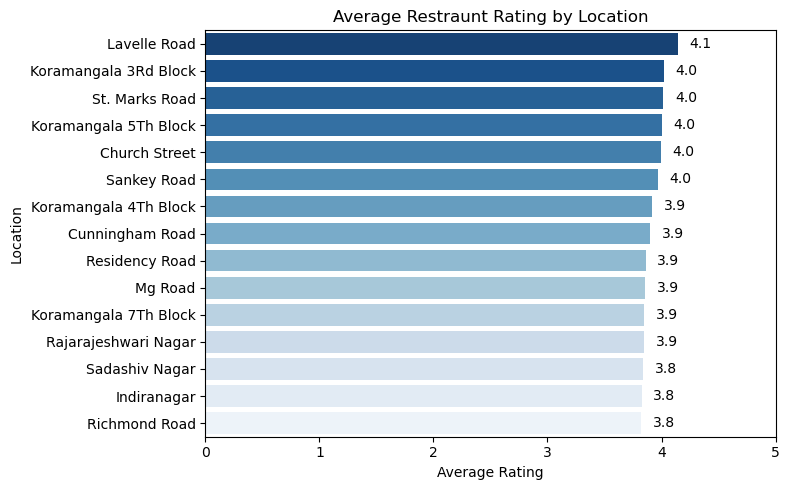

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(x=top_locations.values,y=top_locations.index, palette="Blues_r")
plt.title("Average Restraunt Rating by Location")
plt.xlabel("Average Rating")
plt.ylabel("Location")
plt.xlim(0,5)
for i,v in enumerate(top_locations.values):
    plt.text(v+0.1,i,f"{v:.2}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("plot2_location_ratings.png", dpi=150, bbox_inches="tight")
plt.show()

Restaurants in central upscale corridors like Lavelle Road, Church Street and Koramangala consistently rated above 4.0, suggesting that location significantly influences dining quality or customer expectations. Interestingly, areas like Indiranagar which is also a premium locality, rated lower at 3.8, which may indicate higher competition or more critical customers in that area.

In [24]:
#price vs quality
df["cost_category"]=pd.cut(df["approx_cost(for two people)"],
                          bins=[0,300,600,1000,5000],
                          labels=["Budget(0-300)","Mid(300-600)","Premium(600-1000","Luxury(1000+)"])
cost_ratings = (
    df.groupby("cost_category", observed=True)["rate"]
    .mean()
    .reset_index()
)
cost_ratings

,cost_category,rate
0,Budget(0-300),3.567165
1,Mid(300-600),3.616283
2,Premium(600-1000,3.804262
3,Luxury(1000+),4.129534


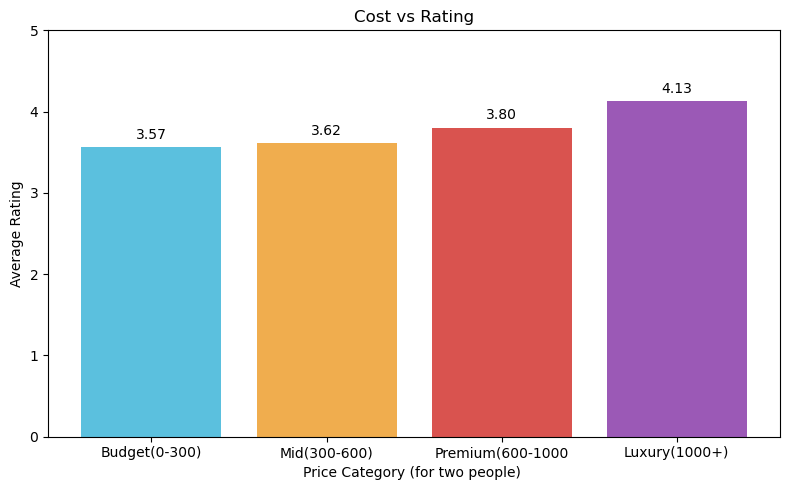

In [25]:
#plot
plt.figure(figsize=(8,5))
colors=["#5bc0de", "#f0ad4e", "#d9534f", "#9b59b6"]
plt.bar(cost_ratings["cost_category"],cost_ratings["rate"],color=colors)
plt.xlabel("Price Category (for two people) ")
plt.ylabel("Average Rating")
plt.title("Cost vs Rating")
plt.ylim(0,5)
for i,v in enumerate(cost_ratings["rate"]):
    plt.text(i,v+0.1,f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("plot_cost_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()

We can observe that rating increases steadily from 3.57 for budget restraunts to 4.13 for luxury ones. However, the difference between budge and luxury is only 0.56, suggesting that while premium restraunts do rate higher, budget restraunts are not rated poorly.

In [26]:
#online order vs rating
order_rating=df.groupby("online_order")["rate"].mean().sort_values(ascending=False)
order_rating

online_order
Yes    3.72244
No     3.65907
Name: rate, dtype: float64

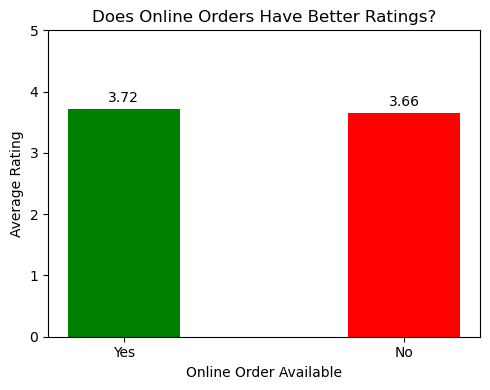

In [27]:
#plot
plt.figure(figsize=(5,4))
plt.bar(order_rating.index,order_rating.values,color=["Green","Red"], width=0.4)
plt.xlabel("Online Order Available")
plt.ylabel("Average Rating")
plt.ylim(0,5)
plt.title("Does Online Orders Have Better Ratings?")
for i,v in enumerate(order_rating.values):
    plt.text(i,v+0.1,f"{v:.2f}",ha="center")

plt.tight_layout()
plt.savefig("plot4_Order_type.png",dpi=150,bbox_inches="tight")
plt.show()

Restaurants accepting online orders rate marginally higher (3.72 vs 3.66), but the difference is too small to conclude that online ordering drives better ratings. It may simply reflect that more established, better run restaurants are more likely to have set up online ordering in the first place.

In [35]:
#restauraunt type vs rating
# making it so that "casual dining, cafe" and "cafe, casual dining" are counted as same
df["rest_type"] = df["rest_type"].apply(lambda x: ", ".join(sorted([i.strip() for i in x.split(",")])) if isinstance(x, str) else x)

#removing restaurants that have less than 100 occurences in the dataset

type_count=df["rest_type"].value_counts()
common_types=type_count[type_count>=100].index
restaurant_type_rating=df[df["rest_type"].isin(common_types)].groupby("rest_type")["rate"].mean().sort_values(ascending=False).head(10)

restaurant_type_rating

rest_type
Microbrewery, Pub              4.447458
Casual Dining, Microbrewery    4.349444
Fine Dining                    4.150146
Cafe, Dessert Parlor           4.142014
Cafe, Casual Dining            4.141344
Casual Dining, Pub             4.122590
Bar, Casual Dining             4.092292
Pub                            3.972159
Bakery, Cafe                   3.968807
Lounge                         3.904987
Name: rate, dtype: float64

C:\Users\Sana Amreen\AppData\Local\Temp\ipykernel_33948\2651563282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=restaurant_type_rating.values, y=restaurant_type_rating.index, palette="coolwarm")


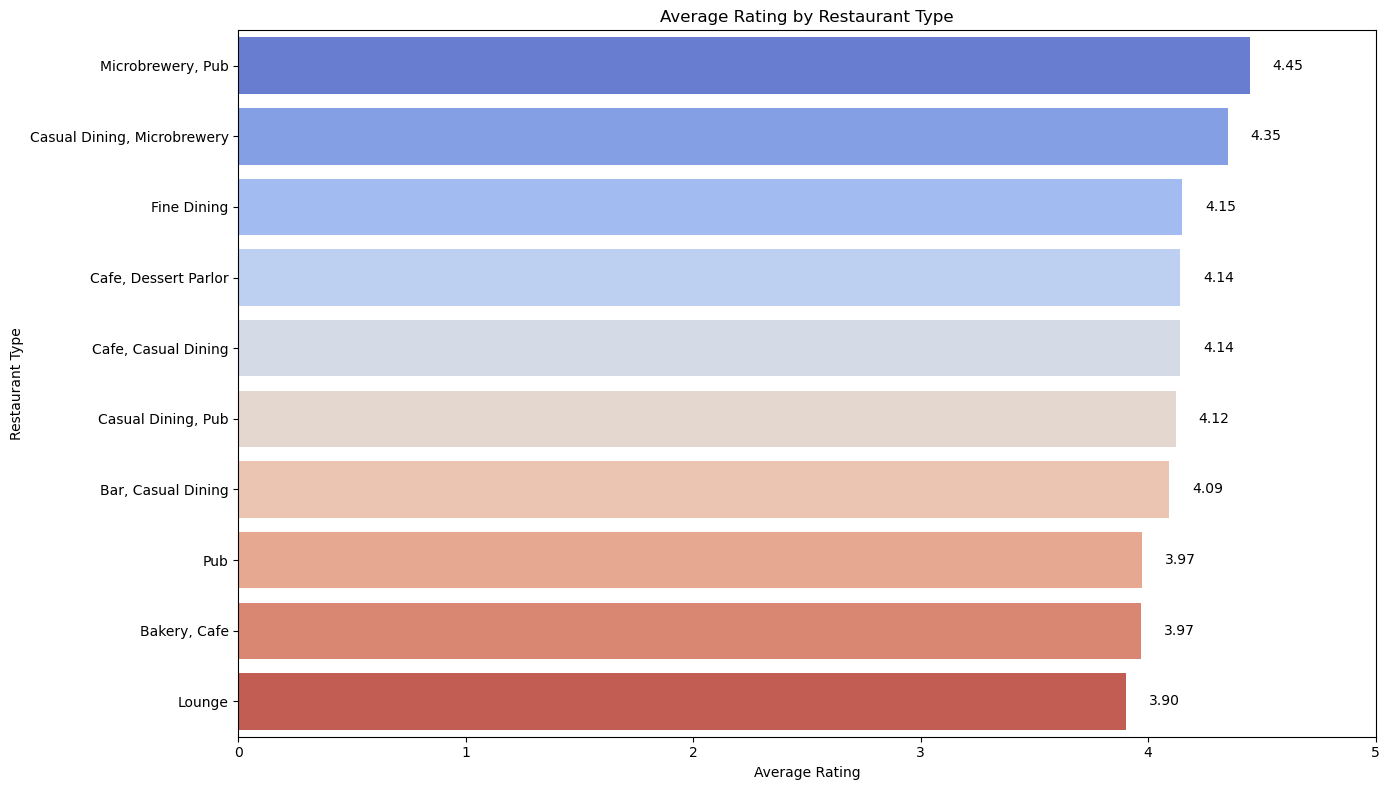

In [36]:
#plot
plt.figure(figsize=(14,8))
sns.barplot(x=restaurant_type_rating.values, y=restaurant_type_rating.index, palette="coolwarm")
plt.title("Average Rating by Restaurant Type")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Type")
plt.xlim(0,5)
for i,v in enumerate(restaurant_type_rating.values):
    plt.text(v+0.1, i, f"{v:.2f}", va="center")
    
plt.tight_layout()
plt.savefig("plot5_rating_by_restaurant_type", dpi=150, bbox_inches="tight")
plt.show()

Experience-led formats like microbreweries and pubs outperform traditional fine dining. The top 7 entries are all combination restaurant types, suggesting that variety of experience within one venue drives higher customer satisfaction. A new restaurant looking to rate well on Zomato should consider offering more than just food

In [30]:
#votes vs rating
#filtering outliers
votes_filtered=df[df["votes"]<df["votes"].quantile(0.99)]
votes_filtered.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city),cuisine_list,cost_category
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555 +91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,"[North Indian, Mughlai, Chinese]",Premium(600-1000
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,"[Chinese, North Indian, Thai]",Premium(600-1000
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,"[Cafe, Mexican, Italian]",Premium(600-1000
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,"[South Indian, North Indian]",Budget(0-300)
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447 +91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,"[North Indian, Rajasthani]",Mid(300-600)


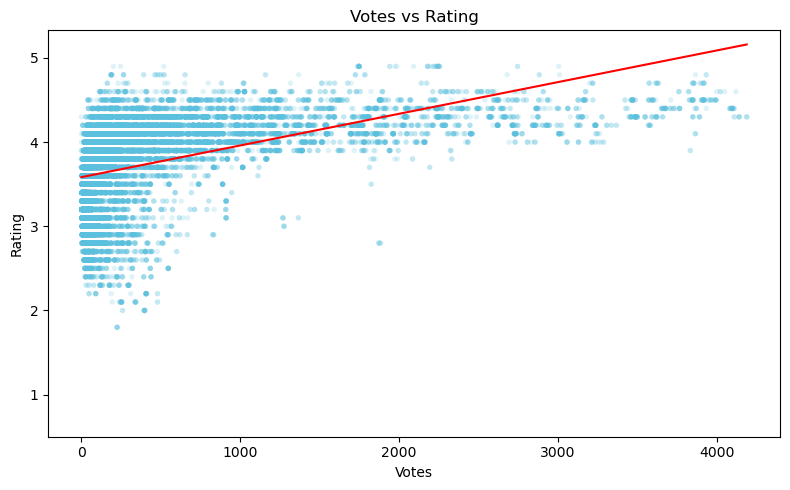

In [31]:
#plot
plt.figure(figsize=(8,5))
plt.scatter(votes_filtered["votes"],votes_filtered["rate"], alpha=0.2,color="#5bc0de", edgecolors="none", s=15)
z=np.polyfit(votes_filtered["votes"].dropna(),votes_filtered["rate"].dropna(),1)
p=np.poly1d(z)
x_line=np.linspace(votes_filtered["votes"].min(),votes_filtered["votes"].max(),100)
plt.plot(x_line,p(x_line),color="red",linewidth=1.5, label="Trend")
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.ylim(0.5)

plt.tight_layout()
plt.savefig("plot5_votes_vs_rating.png",dpi=150,bbox_inches="tight")
plt.show()

In [32]:
corr = votes_filtered[["votes", "rate"]].corr().iloc[0,1]
print(f"Correlation: {corr:.3f}")

Correlation: 0.485


Votes and rating have a moderate positive correlation of 0.46. Popular restaurants tend to rate higher, but popularity alone doesn't guarantee quality. Some heavily voted restaurants rate poorly, suggesting they attract footfall through marketing or location rather than food quality.